In [1]:
import pandas as pd
from glob import glob


results_list = glob("/data1/r20user3/shared_project/Hist2Cell/code/analysis/sptial_colocalization/brca/results/*.csv")
len(results_list)

630

In [2]:
results_df_list = []
for result in results_list:
    df = pd.read_csv(result, index_col=0)
    df['pair'] = df['A'] + " and " + df['B']
    df = df.sort_values(by=['pair'], ascending=[True])
    results_df_list.append(df)

In [3]:
pair_list = results_df_list[0]['pair'].tolist()
pair_list[:5]

['CD4-positive helper T cell and CD4-positive, alpha-beta T cell',
 'CD4-positive helper T cell and CD8-positive, alpha-beta memory T cell',
 'CD4-positive helper T cell and IgA plasma cell',
 'CD4-positive helper T cell and IgG plasma cell',
 'CD4-positive helper T cell and T cell']

In [4]:
sig_count_list = list()
for i in range(len(pair_list)):
    sig_slide_count = 0
    for df in results_df_list:
        if df['R_val'][i] > 0.20:
            sig_slide_count += 1
    sig_count_list.append(sig_slide_count)

In [5]:
# Concatenate the DataFrames in the list
concatenated_df = pd.concat(results_df_list, ignore_index=True)
concatenated_df

,A,B,R_val,R_z_score,R_p_val,pair
0,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell",0.169883,38.815581,0.000000e+00,"CD4-positive helper T cell and CD4-positive, a..."
1,CD4-positive helper T cell,"CD8-positive, alpha-beta memory T cell",0.159772,36.505514,4.533100e-292,"CD4-positive helper T cell and CD8-positive, a..."
2,CD4-positive helper T cell,IgA plasma cell,-0.139912,-31.967700,1.000000e+00,CD4-positive helper T cell and IgA plasma cell
3,CD4-positive helper T cell,IgG plasma cell,-0.102111,-23.330791,1.000000e+00,CD4-positive helper T cell and IgG plasma cell
4,CD4-positive helper T cell,T cell,-0.048419,-11.062910,1.000000e+00,CD4-positive helper T cell and T cell
...,...,...,...,...,...,...
466825,regulatory T cell,vascular associated smooth muscle cell,-0.158573,-26.784151,1.000000e+00,regulatory T cell and vascular associated smoo...
466826,regulatory T cell,vein endothelial cell,0.253919,42.888798,0.000000e+00,regulatory T cell and vein endothelial cell
466827,unswitched memory B cell,vascular associated smooth muscle cell,-0.169188,-28.577038,1.000000e+00,unswitched memory B cell and vascular associat...
466828,unswitched memory B cell,vein endothelial cell,0.251311,42.448330,0.000000e+00,unswitched memory B cell and vein endothelial ...


In [6]:
# Group by columns A and B and calculate the mean of each group
average_df = concatenated_df.groupby(['A', 'B', 'pair']).mean().reset_index()
average_df

,A,B,pair,R_val,R_z_score,R_p_val
0,CD4-positive helper T cell,"CD4-positive, alpha-beta T cell","CD4-positive helper T cell and CD4-positive, a...",0.287321,85.381963,1.465071e-09
1,CD4-positive helper T cell,"CD8-positive, alpha-beta memory T cell","CD4-positive helper T cell and CD8-positive, a...",0.277975,82.564276,2.934510e-09
2,CD4-positive helper T cell,IgA plasma cell,CD4-positive helper T cell and IgA plasma cell,-0.141007,-41.051905,8.661545e-01
3,CD4-positive helper T cell,IgG plasma cell,CD4-positive helper T cell and IgG plasma cell,-0.082933,-23.155591,7.516926e-01
4,CD4-positive helper T cell,T cell,CD4-positive helper T cell and T cell,-0.021836,-6.027987,5.946204e-01
...,...,...,...,...,...,...
736,regulatory T cell,vascular associated smooth muscle cell,regulatory T cell and vascular associated smoo...,-0.132511,-39.377432,8.958507e-01
737,regulatory T cell,vein endothelial cell,regulatory T cell and vein endothelial cell,0.249309,74.100535,1.714475e-02
738,unswitched memory B cell,vascular associated smooth muscle cell,unswitched memory B cell and vascular associat...,-0.132699,-39.884974,8.953832e-01
739,unswitched memory B cell,vein endothelial cell,unswitched memory B cell and vein endothelial ...,0.232810,69.391784,4.067465e-02


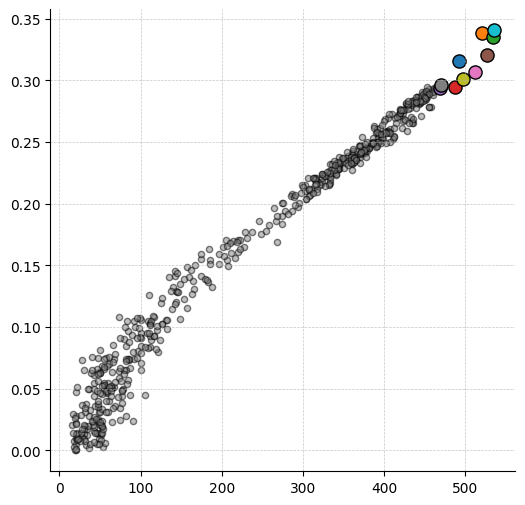

In [7]:
import matplotlib.pyplot as plt
import os


# Filter out the points with y-values less than 0.0
moran_list = average_df['R_val'].to_list()
density_list = sig_count_list
label_list = average_df['pair'].to_list()

# 过滤moran小于0.0的点
filtered_data = [(density, moran, pair_name) for density, moran, pair_name in zip(density_list, moran_list, label_list) if moran > 0.0]

# Create a scatter plot
plt.figure(figsize=(6, 6))  # Set the figure size


label_list = []
# 使用过滤后的数据绘制散点图，并为每个点添加名称
other_label_added = False
for density, moran, pair_name in filtered_data:
    if moran > 0.20 and density > 468:
        plt.scatter(x=density, y=moran, label=pair_name, s=90, edgecolor='black')
        label_list.append(pair_name)
    else:
        if not other_label_added:
            plt.scatter(x=density, y=moran, label="other", c="grey", s=10, alpha=0.8, edgecolor='black')
            other_label_added = True
            label_list.append("other")
        else:
            plt.scatter(x=density, y=moran, c="grey", s=20, alpha=0.5, edgecolor='black')


# Set the title and axis labels
# plt.title("Moran's R vs. Cell Pair Density", fontsize=18)
# plt.xlabel("Cell Pair Density", fontsize=16)
# plt.ylabel(' Moran\'s R', fontsize=16)

# 设置X轴为对数坐标轴
# plt.xscale('log')

# Customize the grid and axis appearance
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 显示图例
# plt.legend(fontsize=6, loc='lower right')

# Set the color of x-axis and y-axis lines to black
ax = plt.gca()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Remove the top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Show the plot
plt.savefig(os.path.join("brca_moransR_vs_sig_slides.svg"), bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

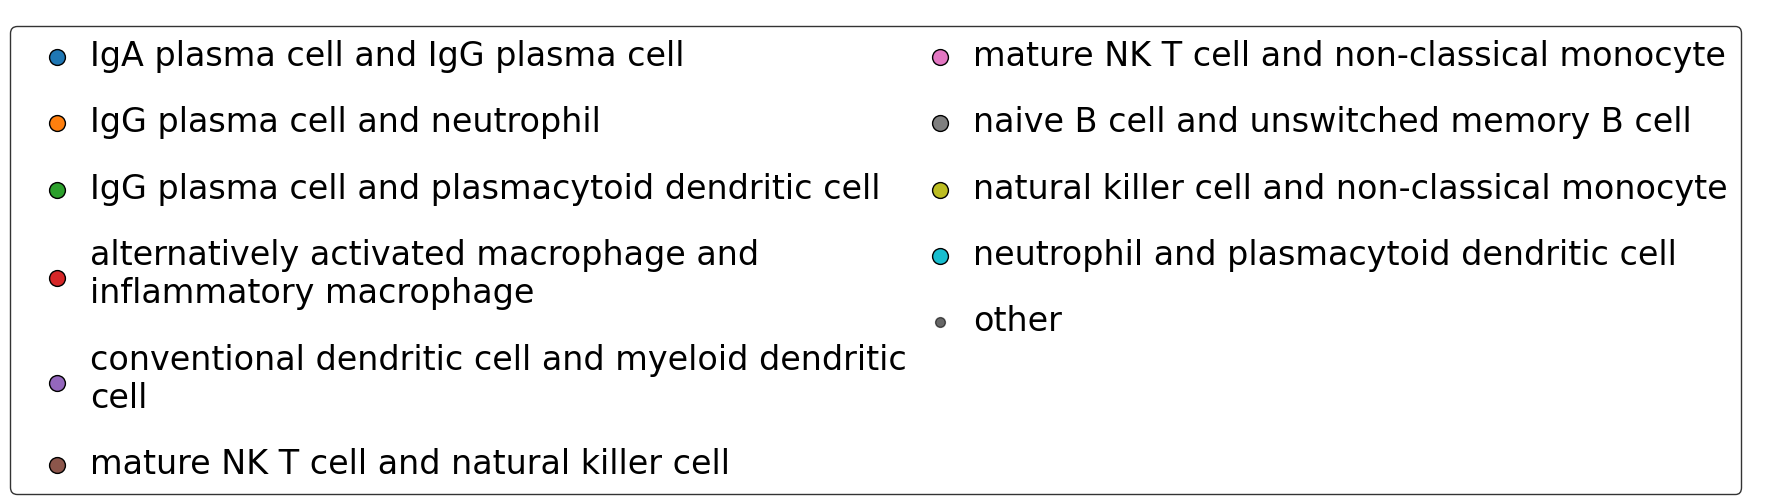

In [36]:
import textwrap

def wrap_labels(ax, width=40):
    """将图例标签换行的函数"""
    labels = [textwrap.fill(label.get_text(), width) for label in ax.get_legend().get_texts()]
    ax.legend(labels, loc="best", labelspacing=1.0, handletextpad=0.0, columnspacing=0.0, handlelength=2, fontsize=24, edgecolor='black', ncol=2)

# 然后创建并保存仅包含图例的图
fig_legend = plt.figure(figsize=(6, 3))
ax_legend = fig_legend.add_subplot(111)
# 使用同样的label和color创建一个空的散点图来生成图例
for label in label_list:
    if label == "other":
        continue
    ax_legend.scatter([], [], label=label, s=130, edgecolor='black')
ax_legend.scatter([], [], label="other", c="black", s=50, alpha=0.6, edgecolor='black')

# 生成图例
ax_legend.legend(fontsize=24, loc='center')
ax_legend.axis('off')

# 调用wrap_labels函数
wrap_labels(ax_legend, width=50)  # 可以调整width以适合您的需求

# Show the plot
plt.savefig("brca_moransR_vs_sig_slides_legend_multicol.svg", bbox_inches='tight', pad_inches=0)
plt.show()
plt.close(fig_legend)